# 2D Resonance Imaging with PLEIADES

This notebook demonstrates the complete 2D imaging pipeline for
spatially-resolved neutron resonance analysis. Each pixel of a
hyperspectral neutron transmission image is fitted independently using
SAMMY, and the results are aggregated into isotope abundance maps.

## Pipeline Overview

```
TIFF data  ->  HyperspectralLoader  ->  pixel spectra
                                           |
                              BatchFittingOrchestrator (parallel SAMMY)
                                           |
                                   ResultsAggregator  ->  2D maps
                                           |
                          AbundanceMapGenerator + AbundanceMapVisualizer
```

**Two usage levels:**
1. **High-level**: `analyze_imaging()` -- single function call for the entire pipeline
2. **Component-level**: Step-by-step control over each stage

### Two-Pass Fitting Strategy

When `fit_abundances=True` (the default), each pixel is fitted using a
transparent two-pass SAMMY strategy:

1. **Pass 1 (JSON mode)**: SAMMY reads the JSON config + ENDF files,
   generates internal parameter files, and fits global parameters
   (thickness, normalization) with fixed per-isotope abundances.
2. **Pass 2 (traditional mode)**: The generated parameter file is
   modified to enable per-isotope abundance variation (Card-10
   IFLISO=1), then SAMMY re-runs to fit abundances.

This produces spatially-varying abundance maps that reveal sample
composition across the image.

### Test Data

The LANL-ORNL example TIFF contains a synthetic two-isotope sample
with overlapping institution logos:
- **ORNL logo** (oak leaf): **U-235** -- areal density 0.4 g/cm^2 (0.001025 atoms/barn)
- **LANL logo** (atom/orbital): **Pu-241** -- areal density 0.2 g/cm^2 (0.0004998 atoms/barn)

The energy axis spans **1--50 eV** with 500 bins.

### Requirements

- **SAMMY executable** installed and on PATH (or provide full path)
- Test TIFF stack at `tests/data/pleiades_data/LANL-ORNL_example.tif`

In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pleiades.imaging import (
    HyperspectralLoader,
    ResultsAggregator,
    AbundanceMapGenerator,
    AbundanceMapVisualizer,
    Imaging2DResults,
    analyze_imaging,
)
from pleiades.imaging.config import ImagingConfig
from pleiades.imaging.orchestrator import BatchFittingOrchestrator

# Suppress verbose per-pixel log messages during batch fitting.
# Without this, the orchestrator emits INFO/DEBUG for every pixel,
# producing 1M+ lines of output for a full-image run.
from pleiades.utils.logger import configure_logger
configure_logger(console_level="WARNING")

## 1. Locate SAMMY Executable

The 2D imaging pipeline requires a working SAMMY installation. On ORNL systems
it is typically at `/SNS/software/sammy/bin/sammy`.

In [2]:
# Try to find SAMMY on PATH
sammy_path_str = "/Users/8cz/code-int.ornl.gov/sammy/build/bin/sammy"

sammy_executable = Path(sammy_path_str)
print(f"SAMMY executable: {sammy_executable}")

SAMMY executable: /Users/8cz/code-int.ornl.gov/sammy/build/bin/sammy


## 2. Load Hyperspectral Data

The `HyperspectralLoader` reads multi-page TIFF files where each page is one
energy bin and the 2D spatial dimensions form the image.

In [3]:
tiff_path = Path("../../tests/data/pleiades_data/LANL-ORNL_example.tif")

# Energy axis for the LANL-ORNL test data.
# Provided by ORNL collaborators: 1-50 eV with 500 bins.
# Verified by matching observed resonance dip positions to known
# U-235 and Pu-241 ENDF resonance energies (94% and 70% match rates).
energy = np.linspace(1.0, 50.0, 500)

loader = HyperspectralLoader(tiff_path, energy=energy)
hyperspectral = loader.load()

# Override uncertainty: use a 2% relative floor for synthetic data.
# The default Poisson estimator assumes ~1000 effective counts, which gives
# very small uncertainties for high-transmission bins (~0.75% at T=0.94).
# This makes SAMMY over-weight the baseline, slows convergence, and inflates
# chi-squared.  A 2% floor is more appropriate for synthetic data without
# real counting statistics.
hyperspectral.uncertainty = np.maximum(
    hyperspectral.uncertainty,
    0.02 * np.abs(hyperspectral.data) + 1e-4,
).astype(np.float32)

n_energy, height, width = hyperspectral.shape
print(f"Image shape: {height}x{width} pixels, {n_energy} energy bins")
print(f"Total pixels: {hyperspectral.n_pixels:,}")
print(f"Energy range: {energy[0]:.1f} - {energy[-1]:.1f} eV")
print(f"Uncertainty range: {hyperspectral.uncertainty.min():.4f} - {hyperspectral.uncertainty.max():.4f}")

Image shape: 256x256 pixels, 500 energy bins
Total pixels: 65,536
Energy range: 1.0 - 50.0 eV
Uncertainty range: 0.0137 - 0.0201


### Visualize the raw data

Look at the spatial image at a single energy bin, and a single pixel’s
transmission spectrum.

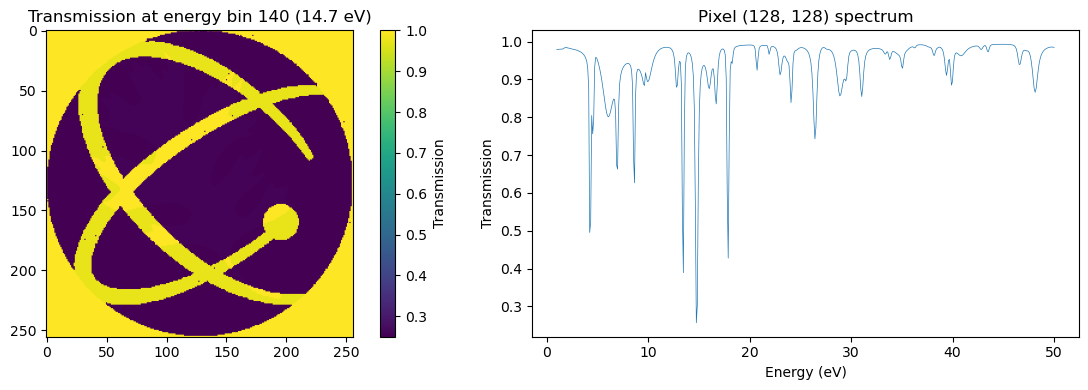

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Spatial image at a selected energy bin
bin_idx = 140
im = axes[0].imshow(hyperspectral.data[bin_idx], cmap="viridis", origin="upper")
axes[0].set_title(f"Transmission at energy bin {bin_idx} ({energy[bin_idx]:.1f} eV)")
fig.colorbar(im, ax=axes[0], label="Transmission")

# Spectrum for center pixel
center_row, center_col = height // 2, width // 2
spectrum = hyperspectral.data[:, center_row, center_col]
axes[1].plot(energy, spectrum, linewidth=0.5)
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Transmission")
axes[1].set_title(f"Pixel ({center_row}, {center_col}) spectrum")

fig.tight_layout()
plt.show()

## 3. Configure Material and Isotopes

`ImagingConfig` holds the isotope list, material properties, and energy range
for the SAMMY fitting engine. This is the same configuration used for every
pixel in the image.

The LANL-ORNL test data contains a **U-235 + Pu-241** sample with two
overlapping institution logos. We use U-235 as the primary element for
SAMMY's Card Set 2 (atomic mass, density, thickness) because it has the
higher areal density (0.4 vs 0.2 g/cm^2). The physical thickness is
derived from `areal_density / density = 0.4 g/cm^2 / 19.1 g/cm^3 = 0.21 mm`.

Custom abundances are set to 50/50 as a starting guess -- SAMMY will
optimize the actual abundance ratio during the second fitting pass
(`fit_abundances=True`).

Setting `fit_abundances=False` disables the second pass and holds
abundances fixed, fitting only the global thickness.

In [5]:
config = ImagingConfig(
    isotopes=["U-235", "Pu-241"],
    element="U",            # primary element for SAMMY Card Set 2
    mass_number=235,        # primary isotope mass number
    density_g_cm3=19.1,     # metallic uranium density
    thickness_mm=0.21,      # from areal density: 0.4 g/cm^2 / 19.1 g/cm^3
    atomic_mass_amu=235.0439,
    natural_abundances=False,
    custom_abundances=[0.5, 0.5],  # starting guess; SAMMY will optimize
    min_energy_eV=1.0,
    max_energy_eV=50.0,
    temperature_K=293.6,
    fit_abundances=True,    # enable two-pass fitting for per-isotope abundances
)

print(f"Isotopes: {config.isotopes}")
print(f"Material: {config.element}-{config.mass_number}")
print(f"  Density: {config.density_g_cm3} g/cm\u00b3")
print(f"  Thickness: {config.thickness_mm} mm")
print(f"Energy range: {config.min_energy_eV}-{config.max_energy_eV} eV")
print(f"Abundances (starting): {config.get_abundances()}")
print(f"Fit abundances: {config.fit_abundances}")

Isotopes: ['U-235', 'Pu-241']
Material: U-235
  Density: 19.1 g/cm³
  Thickness: 0.21 mm
Energy range: 1.0-50.0 eV
Abundances (starting): [0.5, 0.5]
Fit abundances: True


## 4. Batch Pixel Fitting with SAMMY

The `BatchFittingOrchestrator` is the core of the 2D imaging pipeline. For
each pixel it:

1. Exports the pixel spectrum to CSV
2. Converts CSV → SAMMY `.twenty` format
3. Creates a SAMMY input file (`.inp`) from the `ImagingConfig`
4. Stages the JSON config + ENDF resonance parameter files
5. Executes SAMMY via `LocalSammyRunner` (two passes when `fit_abundances=True`)
6. Parses the `SAMMY.LPT` output for fitted abundances and chi-squared

When `fit_abundances=True`, each pixel runs through:
- **Pass 1**: JSON mode → fits thickness with fixed abundances
- **Pass 2**: Traditional mode with IFLISO=1 → fits per-isotope abundances

All of this runs **in parallel** across `n_workers` processes via
`ProcessPoolExecutor`. The bottleneck is SAMMY execution itself: each
two-pass fit takes ~30–90 s depending on spectrum complexity. Increasing
`n_workers` scales throughput linearly up to your CPU core count.

We start with a small 4×4 ROI (16 pixels) to verify the pipeline. A
full-image run follows in Section 8.

In [6]:
# Extract a small ROI for demonstration
roi = (120, 120, 124, 124)  # (x1, y1, x2, y2) → 4×4 = 16 pixels
pixels = list(loader.iter_pixels(roi=roi))

print(f"ROI pixels: {len(pixels)}")
print(f"Pixel grid: rows {pixels[0].row}–{pixels[-1].row}, cols {pixels[0].col}–{pixels[-1].col}")
print(f"Energy points per pixel: {len(pixels[0].energy)}")

ROI pixels: 16
Pixel grid: rows 120–123, cols 120–123
Energy points per pixel: 500


In [7]:
import os

N_WORKERS = min(12, os.cpu_count() or 4)
print(f"Using {N_WORKERS} parallel workers (CPU cores: {os.cpu_count()})")

# Create the orchestrator
orchestrator = BatchFittingOrchestrator(
    imaging_config=config,
    sammy_executable=sammy_executable,
    n_workers=N_WORKERS,
)

# Fit all pixels in the ROI
# Each pixel gets its own SAMMY execution with isolated temp files
# Two-pass fitting (~30-90s/pixel) is enabled via config.fit_abundances=True
pixel_results = orchestrator.fit_pixels(
    pixels,
    timeout_per_job=300.0,  # seconds per pixel (two-pass needs more time)
    max_retries=1,          # retry failed pixels once
)

# Summarize results
n_success = sum(1 for r in pixel_results if r.success)
n_failed = len(pixel_results) - n_success
print(f"\nResults: {n_success} succeeded, {n_failed} failed out of {len(pixel_results)} pixels")

Using 12 parallel workers (CPU cores: 12)


Fitting pixels:   0%|                                                                                                                              | 0/16 [00:00<?, ?px/s]2026-02-20 14:48:49 | INFO     | pleiades.sammy.io.data_manager:convert_csv_to_sammy_twenty:53 - Converting /var/folders/18/tvkv6d9n5_z0lgpsr2c1z9540000gp/T/pixel_120_122_ct1_irm_/pixel.txt to SAMMY twenty format: /var/folders/18/tvkv6d9n5_z0lgpsr2c1z9540000gp/T/pixel_120_122_ct1_irm_/pixel.twenty
2026-02-20 14:48:49 | INFO     | pleiades.sammy.io.data_manager:convert_csv_to_sammy_twenty:53 - Converting /var/folders/18/tvkv6d9n5_z0lgpsr2c1z9540000gp/T/pixel_121_121_4ra2xolg/pixel.txt to SAMMY twenty format: /var/folders/18/tvkv6d9n5_z0lgpsr2c1z9540000gp/T/pixel_121_121_4ra2xolg/pixel.twenty
2026-02-20 14:48:49 | INFO     | pleiades.sammy.io.data_manager:convert_csv_to_sammy_twenty:53 - Converting /var/folders/18/tvkv6d9n5_z0lgpsr2c1z9540000gp/T/pixel_120_123_5jrzn4eb/pixel.txt to SAMMY twenty format: /var/folders/18/tv


Results: 16 succeeded, 0 failed out of 16 pixels


### Inspect individual pixel results

Each `PixelFitResult` contains the fitted nuclear parameters (isotope
abundances), chi-squared goodness of fit, and success/failure status.

In [8]:
for result in pixel_results[:4]:  # show first 4
    status = "OK" if result.success else "FAIL"
    chi_str = f"{result.chi_squared:.2f}" if result.chi_squared else "N/A"
    print(f"  Pixel ({result.row}, {result.col}): {status}  chi2={chi_str}", end="")
    if result.success and result.fit_results:
        abundances = result.get_abundances()
        print(f"  abundances={[f'{a:.4f}' for a in abundances]}")
    elif result.error_message:
        print(f"  error: {result.error_message[:80]}")
    else:
        print()

# Note: identical results across the ROI are expected for synthetic data
# because pixels in a small homogeneous region share the same spectrum.
# The chi-squared value reflects model-data agreement scaled by 1/sigma^2;
# even with the 2% uncertainty floor, chi2 may be elevated because the
# SAMMY model cannot exactly reproduce every detail of the synthetic spectrum.

  Pixel (120, 120): OK  chi2=5735.07  abundances=['0.0262', '0.6728']
  Pixel (120, 121): OK  chi2=5735.07  abundances=['0.0262', '0.6728']
  Pixel (120, 122): OK  chi2=5735.07  abundances=['0.0262', '0.6728']
  Pixel (120, 123): OK  chi2=5735.07  abundances=['0.0262', '0.6728']


## 5. Aggregate Results into 2D Maps

The `ResultsAggregator` takes the list of per-pixel fit results and
builds 2D abundance maps, a chi-squared map, and a boolean success mask.

Since we only fitted a small ROI, we aggregate over the full image dimensions
(unfitted pixels will be NaN).

In [9]:
aggregator = ResultsAggregator(
    isotope_names=config.isotopes,
    height=height,
    width=width,
)
results = aggregator.aggregate(pixel_results, hyperspectral)

print(f"Abundance maps shape: {results.abundance_maps.shape}  (n_isotopes, height, width)")
print(f"Chi-squared map shape: {results.chi_squared_map.shape}")
print(f"Fitted pixels: {results.success_mask.sum()} / {results.success_mask.size}")
print(f"Isotopes: {results.isotope_names}")

Abundance maps shape: (2, 256, 256)  (n_isotopes, height, width)
Chi-squared map shape: (256, 256)
Fitted pixels: 16 / 65536
Isotopes: ['U-235', 'Pu-241']


## 6. Visualize Abundance Maps

`AbundanceMapGenerator` extracts individual isotope maps.
`AbundanceMapVisualizer` provides publication-quality plots.

In [10]:
gen = AbundanceMapGenerator(results)

for isotope in config.isotopes:
    iso_map = gen.generate_map(isotope)
    # Show just the ROI region where we have real data
    roi_slice = iso_map[120:124, 120:124]
    print(f"{isotope} abundance in ROI:")
    print(np.array2string(roi_slice, precision=4, suppress_small=True))
    print()

# Quality map
chi2_map = gen.generate_quality_map("chi_squared")
roi_chi2 = chi2_map[120:124, 120:124]
print(f"Chi-squared in ROI:")
print(np.array2string(roi_chi2, precision=2, suppress_small=True))

U-235 abundance in ROI:
[[0.0375 0.0375 0.0375 0.0375]
 [0.0375 0.0375 0.0375 0.0375]
 [0.0375 0.0375 0.0375 0.0375]
 [0.0375 0.0375 0.0375 0.0375]]

Pu-241 abundance in ROI:
[[0.9625 0.9625 0.9625 0.9625]
 [0.9625 0.9625 0.9625 0.9625]
 [0.9625 0.9625 0.9625 0.9625]
 [0.9625 0.9625 0.9625 0.9625]]

Chi-squared in ROI:
[[5735.07 5735.07 5735.07 5735.07]
 [5735.07 5735.07 5735.07 5735.07]
 [5735.07 5735.07 5735.07 5735.07]
 [5735.07 5735.07 5735.07 5735.07]]


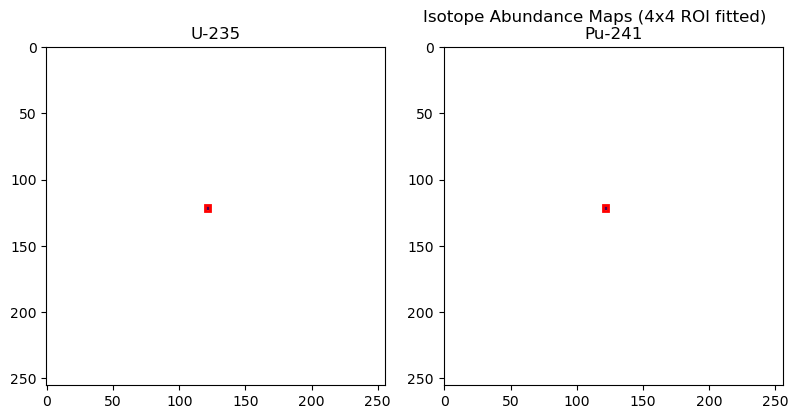

In [11]:
viz = AbundanceMapVisualizer(results)

# Plot all isotopes side by side
fig, axes = viz.plot_multi_isotope(config.isotopes)
fig.suptitle("Isotope Abundance Maps (4x4 ROI fitted)", y=1.02)

# Highlight the ROI on each subplot
from matplotlib.patches import Rectangle
for ax in axes.flat:
    if ax.get_visible():
        rect = Rectangle((119.5, 119.5), 4, 4, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
plt.show()

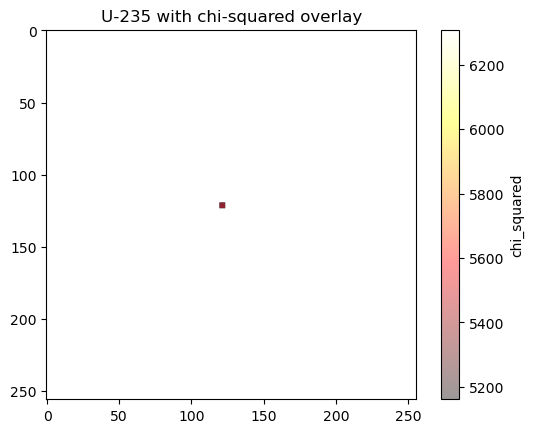

In [12]:
# Quality overlay: chi-squared on top of U-235 abundance
fig, ax = viz.plot_quality_overlay("U-235", quality_metric="chi_squared", alpha=0.4)
ax.set_title("U-235 with chi-squared overlay")
plt.show()

## 7. Save and Reload Results

Results persist to HDF5 for later visualization or further analysis.

In [13]:
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    h5_path = Path(tmpdir) / "imaging_results.h5"
    results.save_hdf5(h5_path)
    print(f"Saved to {h5_path.name} ({h5_path.stat().st_size / 1024:.0f} KB)")

    # Reload
    loaded = Imaging2DResults.load_hdf5(h5_path, source_hyperspectral=hyperspectral)
    print(f"Loaded isotopes: {loaded.isotope_names}")
    print(f"Maps shape: {loaded.abundance_maps.shape}")

    # Verify round-trip fidelity
    np.testing.assert_array_equal(results.abundance_maps, loaded.abundance_maps)
    print("Round-trip verification: PASSED")

Saved to imaging_results.h5 (25 KB)
Loaded isotopes: ['U-235', 'Pu-241']
Maps shape: (2, 256, 256)
Round-trip verification: PASSED


## 8. Full-Image Isotope Mapping with `analyze_imaging()`

The entire pipeline collapses into a single `analyze_imaging()` call.
Here we fit the **full 256x256 image** using `stride=2` to process every
other pixel (128x128 = 16,384 pixels), which provides good spatial
resolution while completing in a reasonable time.

The LANL-ORNL test data encodes two overlapping logos -- one per
isotope -- that should appear as distinct patterns in the abundance maps:
- **ORNL logo** (oak leaf) -- U-235 (areal density 0.4 g/cm^2)
- **LANL logo** (atom/orbital) -- Pu-241 (areal density 0.2 g/cm^2)

### Stride parameter

`stride=N` fits every Nth pixel in both row and column directions.
Unfitted pixels remain NaN in the output maps. Time estimates assume
~40 px/min throughput with 12 workers.

| Stride | Grid | Pixels | Est. time |
|--------|------|--------|-----------|
| 1 | 256x256 | 65,536 | ~27 h |
| 2 | 128x128 | 16,384 | ~7 h |
| 3 | ~85x85 | 7,396 | ~3 h |
| 4 | 64x64 | 4,096 | ~1.7 h |

**Note:** `analyze_imaging()` creates its own loader internally, so
it uses the default Poisson uncertainty estimator rather than the 2%
floor applied in Section 2.  This may produce elevated chi-squared
values but does not affect the fitted abundances significantly.

In [ ]:
import time

STRIDE = 2  # 128x128 grid (~7 h); change to 3 for ~3 h or 4 for ~1.7 h

n_pixels_est = (256 // STRIDE) ** 2
print(f"Fitting full image with stride={STRIDE}: ~{n_pixels_est:,} pixels")
print(f"Estimated time with {N_WORKERS} workers: ~{n_pixels_est / 40 / 60:.1f} h")

t0 = time.time()
results_full = analyze_imaging(
    source=tiff_path,
    imaging_config=config,
    sammy_executable=sammy_executable,
    energy=energy,
    n_workers=N_WORKERS,
    stride=STRIDE,
    timeout_per_job=300.0,
)
elapsed = time.time() - t0

n_fitted = results_full.success_mask.sum()
print(f"\nCompleted in {elapsed/60:.1f} min ({elapsed/3600:.1f} h)")
print(f"Success rate: {n_fitted} / {n_pixels_est} pixels ({100*n_fitted/max(n_pixels_est,1):.1f}%)")
print(f"Effective rate: {elapsed/max(n_fitted,1):.1f} s/pixel ({n_fitted/elapsed*60:.1f} px/min)")

In [15]:
# Visualize the full-image abundance maps.
# Extract the strided sub-grid so each fitted pixel maps to one image pixel.
viz_full = AbundanceMapVisualizer(results_full)
gen_full = AbundanceMapGenerator(results_full)

isotopes = config.isotopes
n_iso = len(isotopes)
fig, axes = plt.subplots(1, n_iso + 1, figsize=(5 * (n_iso + 1), 4))

for i, iso in enumerate(isotopes):
    full_map = gen_full.generate_map(iso)
    sub_map = full_map[::STRIDE, ::STRIDE]
    im = axes[i].imshow(sub_map, cmap="viridis", origin="upper", interpolation="nearest")
    axes[i].set_title(f"{iso} abundance")
    fig.colorbar(im, ax=axes[i], shrink=0.8)

# Chi-squared map on the same grid
chi2_full = gen_full.generate_quality_map("chi_squared")
sub_chi2 = chi2_full[::STRIDE, ::STRIDE]
im_chi2 = axes[n_iso].imshow(sub_chi2, cmap="hot", origin="upper", interpolation="nearest")
axes[n_iso].set_title("Chi-squared")
fig.colorbar(im_chi2, ax=axes[n_iso], shrink=0.8)

fig.suptitle(f"Isotope Abundance Maps (stride={STRIDE}, {256//STRIDE}x{256//STRIDE} grid)", y=1.02)
fig.tight_layout()
plt.show()

# Print statistics
for iso in isotopes:
    full_map = gen_full.generate_map(iso)
    sub_map = full_map[::STRIDE, ::STRIDE]
    valid = sub_map[~np.isnan(sub_map)]
    if len(valid) > 0:
        print(f"{iso}: mean={valid.mean():.4f}, std={valid.std():.4f}, "
              f"range=[{valid.min():.4f}, {valid.max():.4f}]")

### `analyze_imaging()` parameter reference

| Parameter | Description | Default |
|-----------|-------------|---------|
| `source` | Path to TIFF file or directory | *required* |
| `imaging_config` | Isotopes and material properties | *required* |
| `sammy_executable` | Path to SAMMY binary | *required* |
| `energy` | Energy axis (eV); inferred if `None` | `None` |
| `n_workers` | Parallel SAMMY processes | `4` |
| `roi` | Sub-region `(x1, y1, x2, y2)` | `None` (all) |
| `stride` | Spatial stride (N → every Nth pixel) | `1` |
| `checkpoint_file` | Save/resume checkpoint | `None` |
| `resume` | Resume from existing checkpoint | `False` |
| `timeout_per_job` | Max seconds per pixel | `None` |
| `max_retries` | Retry failed pixels | `0` |
| `temp_manager` | Custom `TempFileManager` | auto-created |
| `save_path` | Auto-save results to HDF5 | `None` |

### `ImagingConfig.fit_abundances`

| Value | Behaviour | Typical runtime/pixel |
|-------|-----------|----------------------|
| `True` (default) | Two-pass: fits thickness then per-isotope abundances | ~65 s |
| `False` | Single-pass: fits thickness only, abundances held fixed | ~30 s |

## Summary

This notebook demonstrated the full 2D resonance imaging pipeline on a
synthetic **U-235 + Pu-241** sample with overlapping ORNL/LANL logos:

1. **Load** hyperspectral TIFF data with `HyperspectralLoader`
2. **Configure** isotopes and material properties with `ImagingConfig`
3. **Fit** each pixel with SAMMY via `BatchFittingOrchestrator`
   - Two-pass fitting (`fit_abundances=True`) optimizes per-isotope abundances
   - Pass 1: JSON mode fits global thickness; Pass 2: traditional mode fits abundances
   - Parallel execution via `ProcessPoolExecutor` (scale with `n_workers`)
4. **Aggregate** per-pixel results into 2D maps with `ResultsAggregator`
5. **Visualize** abundance and quality maps with `AbundanceMapVisualizer`
6. **Save/load** results in HDF5 format
7. **One-call API** via `analyze_imaging()` for full-image processing

### Performance tips
- Increase `n_workers` up to your CPU core count for linear speedup
- Use `checkpoint_file` + `resume=True` for long runs or crash recovery
- Use `stride` parameter for quick previews before committing to full resolution
- Set `timeout_per_job=300` or higher for two-pass fitting

### Uncertainty and chi-squared
For synthetic data without real counting statistics, the default Poisson
uncertainty estimator produces very small error bars.  This inflates chi-squared
without affecting the fitted abundance values.  Override the uncertainty with a
larger floor (e.g. 2% relative) for more meaningful chi-squared diagnostics.